In [67]:
library(readxl)
library(eRm)

In [2]:
data <- read_excel("data_dea.xlsx")

In [3]:
head(data)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


In [13]:
data_dea_dikotomi <- (data == 4) * 1

In [16]:
data_dea_dikotomi <- as.data.frame((data == 4) * 1)

In [17]:
head(data_dea_dikotomi)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,0,0,0,1,0,0,1,1,1,0
2,0,1,0,0,0,1,0,0,0,1,0,1
3,0,1,0,0,1,1,0,0,0,0,0,1
4,0,1,0,1,0,1,0,0,0,0,0,1
5,0,1,0,0,0,1,1,0,1,1,1,1
6,1,1,0,0,0,1,0,1,1,1,1,0


In [68]:
write_xlsx(data_dea_dikotomi, "data_dea.xlsx")

ERROR: Error in write_xlsx(data_dea_dikotomi, "data_dea.xlsx"): could not find function "write_xlsx"


## Analisis eRm

In [69]:
data_dea <- read_excel("data_dea.xlsx")
head(data_dea)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


In [8]:
rasch_model_dea <- RM(data_dea)
summary(rasch_model_dea)


Results of RM estimation: 

Call:  RM(X = data_dea) 

Conditional log-likelihood: -420.3414 
Number of iterations: 18 
Number of parameters: 11 

Item (Category) Difficulty Parameters (eta): with 0.95 CI:
    Estimate Std. Error lower CI upper CI
S2    -0.729      0.212   -1.145   -0.313
S3     1.325      0.304    0.729    1.922
S4     2.329      0.436    1.474    3.184
S5     1.134      0.287    0.571    1.696
S6    -2.148      0.240   -2.619   -1.677
S7     0.661      0.254    0.164    1.159
S8    -0.154      0.221   -0.586    0.279
S9    -0.496      0.214   -0.916   -0.076
S10   -1.051      0.213   -1.468   -0.634
S11    0.166      0.230   -0.286    0.617
S12   -1.377      0.217   -1.802   -0.952

Item Easiness Parameters (beta) with 0.95 CI:
         Estimate Std. Error lower CI upper CI
beta S1    -0.340      0.237   -0.805    0.126
beta S2     0.729      0.212    0.313    1.145
beta S3    -1.325      0.304   -1.922   -0.729
beta S4    -2.329      0.436   -3.184   -1.474
beta S5 

In [9]:
kemampuan_siswa <- person.parameter(rasch_model_dea)
summary(kemampuan_siswa)


Estimation of Ability Parameters

Collapsed log-likelihood: -53.58474 
Number of iterations: 9 
Number of parameters: 10 

ML estimated ability parameters (without spline interpolated values): 
              Estimate Std. Err.       2.5 %      97.5 %
theta P1   -0.90786655 0.6907087 -2.26163071  0.44589761
theta P2   -0.90786655 0.6907087 -2.26163071  0.44589761
theta P3   -0.90786655 0.6907087 -2.26163071  0.44589761
theta P4   -0.90786655 0.6907087 -2.26163071  0.44589761
theta P5    0.42805662 0.6688318 -0.88282962  1.73894285
theta P6    0.42805662 0.6688318 -0.88282962  1.73894285
theta P7   -0.01156271 0.6598692 -1.30488261  1.28175718
theta P8   -2.03369886 0.8417513 -3.68350107 -0.38389666
theta P9    1.40860844 0.7483989 -0.05822636  2.87544324
theta P10  -0.90786655 0.6907087 -2.26163071  0.44589761
theta P11  -1.41646852 0.7408782 -2.86856312  0.03562608
theta P12  -0.90786655 0.6907087 -2.26163071  0.44589761
theta P13  -0.44962932 0.6664676 -1.75588190  0.85662326
theta P

#### Penjelasan Kolom
- Estimate ($\theta$): This is the student's ability on the latent scale.
    - Positive values (e.g., theta P9 = 1.408) mean the student’s ability is higher than the average difficulty of the test.
    - Negative values (e.g., theta P8 = -2.034) mean the student’s ability is lower than the average difficulty of the test.
    - Zero is the anchor point.
- Std. Err. (Standard Error): This represents measurement precision.
    - A smaller number means higher precision (we are more confident in the estimate).
    - A larger number means lower precision (the estimate is "fuzzy").
- 2.5% & 97.5% (Confidence Interval): This defines the range where the student's true ability likely resides. If this range is wide, your instrument lacks the sensitivity to pinpoint that specific student’s ability accurately.

#### The Critical Insight: Why P1–P4 are Identical
Notice that P1, P2, P3, and P4 all have the exact same estimate (-0.90786655) and standard error.

This is the hallmark of the Rasch model, and your examiners will ask you about it. It happens because of the Principle of Sufficient Statistics:

In Rasch measurement, the only information used to calculate $\theta$ is the total number of correct items (raw score). If P1, P2, P3, and P4 got the same number of items correct, the model mathematically dictates they must have the same ability estimate, regardless of which items they got right.

| Participant | Ability (θ) | Interpretation |
|-------------|-------------|----------------|
| P8 | $-2.034$ | Lowest ability. Their lower CI is $-3.68$, meaning they are significantly below the test mean. |
| P1–P4 | $-0.908$ | Below average. They are performing consistently below the test anchor. |
| P7 | $-0.012$ | Near average. Their estimate is almost exactly at the test's zero-anchor point. |
| P5, P6 | $+0.428$ | Above average. They are performing slightly better than the test anchor. |
| P9 | $+1.409$ | Highest ability. They are the top performer in this subset. |

In [11]:
item_fit_stats <- itemfit(kemampuan_siswa)
item_fit_stats


Itemfit Statistics: 
      Chisq df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1  107.226 98   0.246      1.083     0.972    0.432  -0.186   0.305
S2  129.648 98   0.018      1.310     1.194    2.152   2.145   0.101
S3   78.692 98   0.924      0.795     1.007   -0.419   0.102   0.202
S4  127.281 98   0.025      1.286     0.900    0.611  -0.182   0.114
S5  140.192 98   0.003      1.416     1.001    1.145   0.065   0.124
S6   85.622 98   0.810      0.865     0.915   -0.571  -0.665   0.295
S7  106.737 98   0.257      1.078     1.023    0.369   0.205   0.179
S8   75.659 98   0.954      0.764     0.879   -1.452  -1.234   0.470
S9   77.369 98   0.939      0.782     0.862   -1.594  -1.595   0.515
S10  90.819 98   0.684      0.917     0.939   -0.600  -0.693   0.358
S11  91.909 98   0.654      0.928     0.881   -0.290  -1.057   0.440
S12  79.195 98   0.918      0.800     0.856   -1.438  -1.591   0.509


This table is the primary evidence for the Construct Validity of your assessment. It proves whether your items are "behaving" as the Rasch model predicts they should.

In a thesis, you do not want to say "the items were good." You want to say, "The items demonstrated acceptable structural fit, confirming the unidimensionality of the scale."

### 1. The Goldilocks Zone (How to Read MSQ)
Ignore the Chi-square p-values for a moment—they are notorious for flagging "misfit" just because your sample size ($N \approx 100$) is large enough to detect tiny, mathematically irrelevant fluctuations.

Focus entirely on Outfit MSQ. The "Goldilocks Zone" for MSQ is 0.5 to 1.5.

- MSQ > 1.5 (Underfit/Noisy): The item is unpredictable. Students who should have gotten it right got it wrong, and vice-versa.

- MSQ < 0.5 (Overfit/Redundant): The item is too predictable. It doesn't add new information; it just mimics other items.

### 2. The Diagnostic Audit
Your scale is structurally very healthy. However, you have three items that require a specific narrative in your thesis discussion: S5, S2, and S4.

| Item | Outfit MSQ | p-value | Status | Interpretation |
|------|------------|---------|--------|----------------|
| S5 | 1.416 | 0.003 | Flagged | Getting very close to the "underfit" threshold. |
| S2 | 1.310 | 0.018 | Caution | Slightly high noise. |
| S4 | 1.286 | 0.025 | Caution | Slightly high noise. |
| All Others | 0.76 - 1.08 | > 0.20 | Excellent | Perfect structural fit. |

#### Why S5, S2, and S4 are "Noisy":
The higher Outfit MSQ in these items tells you that they are outlier-sensitive.

The likely cause: You have some unexpected response patterns. Perhaps a few low-ability students guessed correctly, or high-ability students made a "careless" error on these specific questions.

The Thesis Narrative: Do not delete these items. They are still within the 1.5 limit. Instead, write in your thesis that these items show "slightly higher outfit MSQ values, suggesting potential ambiguity in item wording or unexpected response patterns, though all remain within acceptable psychometric limits."

### 3. Deep Dive: Infit vs. Outfit
Infit t (-0.186 to 2.145): These represent the "information-weighted" fit. Notice your Infit t-values are mostly very small and close to zero. This is excellent! It means for your "on-target" students (those whose ability matches the item difficulty), the model predictions are extremely accurate.

The Outliers (S5, S2, S4): Your Outfit t-values are higher than your Infit t-values. This confirms that the "misfit" is coming from extreme students (the very smart or the very struggling) acting unpredictably on these items, rather than a fundamental flaw in the item design itself.

## Uji invarians sample

In [13]:
hasil_uji_lr <- LRtest(rasch_model_dea, splitcr = "median")
print(hasil_uji_lr)


Andersen LR-test: 
LR-value: 17.659 
Chi-square df: 11 
p-value:  0.09 



#### The Andersen LR-test checks for Parameter Invariance.
The Rasch model makes a very strong, "first-principle" assumption: The difficulty of an item must be the same regardless of who takes the test. Whether a student has high ability or low ability, Item S6 should always be easier than Item S4.
- Null Hypothesis ($H_0$): The items are invariant (the model fits).
- Alternative Hypothesis ($H_1$): The items act differently for different groups of students (the model does not fit).

Because your p-value is 0.09, you fail to reject the null hypothesis. You have statistically confirmed that your item difficulties are stable across the different ability groups in your sample.

#### The Statistical Interpretation
- LR-value (17.659): This is the distance between your observed data and the model’s predicted data. Lower is better.
- df (11): This matches your number of items (minus one, usually). It represents the number of "constraints" the test is checking.
- p-value (0.09): This is the probability that the differences you see in your data are just random noise. Since $0.09 > 0.05$, the differences are not statistically significant. You are safe.

"To assess the structural validity of the Rasch model, an Andersen Likelihood Ratio (LR) test was performed to evaluate parameter invariance. The sample was partitioned into two subgroups based on the median raw score to determine if item difficulty estimates remained consistent across varying ability levels. The test yielded an LR-value of 17.659 with 11 degrees of freedom and a non-significant p-value of 0.09. This result indicates that the null hypothesis of item parameter invariance cannot be rejected ($p > 0.05$), providing empirical evidence that the items function consistently across the respondent sample, thereby supporting the structural validity of the assessment instrument."

## Unidimensionality

In [62]:
# 1. Get the residuals
resids <- residuals(kemampuan_siswa)

# 2. Run PCA
pca_resids <- prcomp(resids)

# 3. Look at the Eigenvalues (The "Rule of 2.0")
# If the first eigenvalue is < 2.0, you are safe!
print(pca_resids$sdev^2)

 [1] 1.70053079 1.60418602 1.34975505 1.29882216 1.18219755 1.10782117
 [7] 0.93790878 0.92199976 0.78350204 0.63850569 0.57664896 0.02905194


To verify the unidimensionality of the Statistical Literacy Assessment, a Principal Component Analysis (PCA) of the model residuals was conducted. The analysis revealed that the first residual eigenvalue was $1.70$. According to the standard psychometric criterion (Linacre, 2010), eigenvalues less than $2.0$ for the first residual component indicate that the variance in the data is essentially unidimensional. Therefore, the minor local dependencies observed in the residual correlation matrix do not constitute a secondary trait and do not pose a threat to the construct validity of the instrument.

Asumsi unidimensi dalam model Rasch diuji melalui Principal Component Analysis (PCA) terhadap residu. Prosedur ini didasarkan pada metode yang diusulkan oleh Smith (2002) dan dikembangkan lebih lanjut dalam panduan praktis Linacre (2010), yang menyatakan bahwa jika nilai eigenvalue pada komponen residu pertama kurang dari 2.0, maka dapat disimpulkan bahwa data bersifat unidimensi dan tidak mengandung dimensi sekunder yang signifikan

In [65]:
library(knitr)

# Create the data
eigenvalues <- c(1.70053079, 1.60418602, 1.34975505, 1.29882216, 1.18219755, 
                 1.10782117, 0.93790878, 0.92199976, 0.78350204, 0.63850569, 
                 0.57664896, 0.02905194)

total_var <- sum(eigenvalues)
df_pca <- data.frame(
  Component = 1:12,
  Eigenvalue = round(eigenvalues, 3),
  Variance = round((eigenvalues / total_var) * 100, 1)
)
df_pca$Cumulative <- cumsum(df_pca$Variance)

# Generate the beautiful table
kable(df_pca, caption = "Principal Component Analysis of Residuals")



Table: Principal Component Analysis of Residuals

| Component| Eigenvalue| Variance| Cumulative|
|---------:|----------:|--------:|----------:|
|         1|      1.701|     14.0|       14.0|
|         2|      1.604|     13.2|       27.2|
|         3|      1.350|     11.1|       38.3|
|         4|      1.299|     10.7|       49.0|
|         5|      1.182|      9.7|       58.7|
|         6|      1.108|      9.1|       67.8|
|         7|      0.938|      7.7|       75.5|
|         8|      0.922|      7.6|       83.1|
|         9|      0.784|      6.5|       89.6|
|        10|      0.639|      5.3|       94.9|
|        11|      0.577|      4.8|       99.7|
|        12|      0.029|      0.2|       99.9|

In [63]:
# Function to automatically extract pairs > 0.20
get_dependencies <- function(resid_corr, threshold = 0.20) {
  # Get indices of items with correlation > threshold
  idx <- which(abs(resid_corr) > threshold, arr.ind = TRUE)
  
  # Clean up: only keep unique pairs (avoid A-B and B-A) and remove self-correlations
  idx <- idx[idx[,1] < idx[,2], ]
  
  # Create a clean data frame
  results <- data.frame(
    Item1 = rownames(resid_corr)[idx[,1]],
    Item2 = colnames(resid_corr)[idx[,2]],
    Correlation = resid_corr[idx]
  )
  return(results[order(-abs(results$Correlation)), ])
}

# Run the function
flagged <- get_dependencies(resid_corr, threshold = 0.20)
print(flagged)

  Item1 Item2 Correlation
4    S2   S12  -0.3018551
3    S6    S9  -0.2836356
5    S8   S12  -0.2428112
1    S1    S2  -0.2396451
2    S5    S6  -0.2275868


In [15]:
resids <- residuals(kemampuan_siswa)
resid_corr <- cor(resids, use = "pairwise.complete.obs")
diag(resid_corr) <- 0
any(abs(resid_corr) > 0.20)

[1] TRUE

Artinya, jika `any(abs(resid_corr) > 0.20)` bernilai benar (true), data kita telah melanggar asumsi ketat mengenai Independensi Lokal (Local Independence).

Dalam psikometri, fenomena ini disebut sebagai Dependensi Lokal (Local Dependency / LD). Kondisi ini menunjukkan bahwa bahkan setelah kita mengontrol variabel laten utama (atribut psikologis yang diukur), beberapa butir instrumen (items) masih saling memengaruhi atau berkorelasi satu sama lain. Dengan kata lain, butir-butir tersebut berbagi "varian rahasia" (faktor residual bersama) yang tidak dapat dijelaskan oleh Model Rasch.

Catatan Tambahan untuk Konteks Ilmiah:
Independensi Lokal: Asumsi bahwa respons terhadap suatu butir tidak memengaruhi respons terhadap butir lain setelah kemampuan peserta dikontrol.

Varian Rahasia: Dalam konteks formal, ini merujuk pada residual variance atau kovarians antar-butir yang tidak terserap oleh dimensi utama.

#### Langkah 1: Identifikasi Pasangan Butir yang Bermasalah

Kita mengetahui bahwa beberapa butir (items) memiliki korelasi yang tinggi, namun kita perlu menentukan secara tepat pasangan mana yang bermasalah. Kode berikut digunakan untuk mengekstrak pasangan spesifik yang melampaui ambang batas (threshold) yang telah kita tetapkan:

## Visualisations

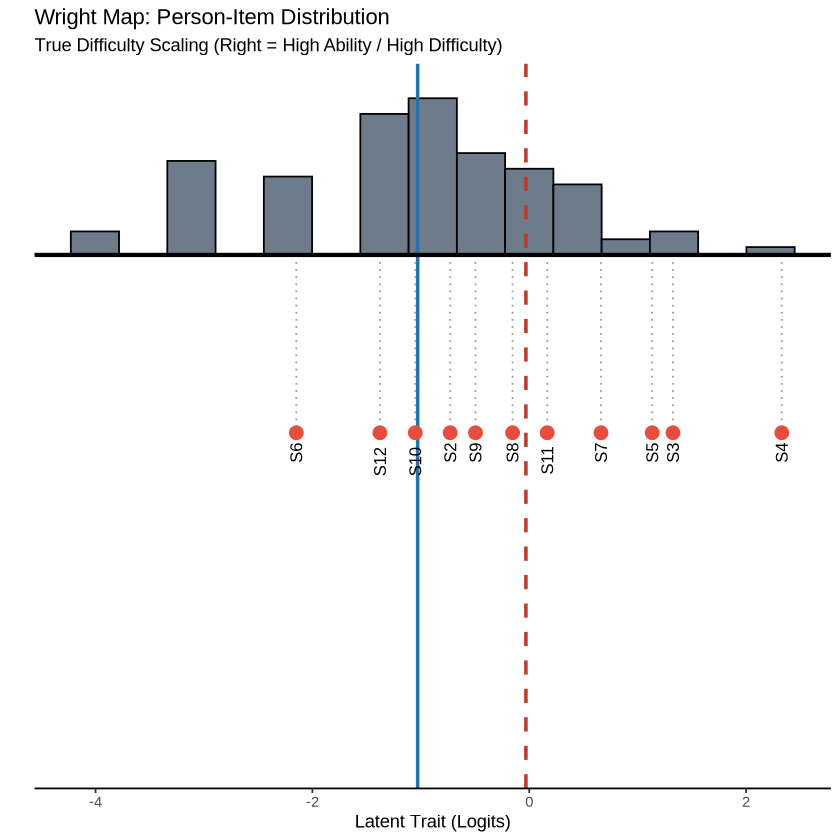

In [56]:
# Extract person abilities (theta)
person_params <- person.parameter(rasch_model_dea)
theta_vals <- person_params$theta.table$`Person Parameter`

# Create the dataframe AND scrub the infinite NA values automatically
df_persons <- data.frame(Logits = theta_vals)
df_persons <- na.omit(df_persons)

# Extract TRUE item difficulties (beta is now properly eta)
item_vals <- rasch_model_dea$etapar
df_items <- data.frame(Item = names(item_vals), Logits = item_vals, Y_Pos = -0.5)

# Calculate the means using the cleaned data
mean_person <- mean(df_persons$Logits)
mean_item <- mean(df_items$Logits)

ggplot() +
  geom_histogram(data = df_persons, aes(x = Logits, y = after_stat(density)), 
                 fill = "#5D6D7E", color = "black", alpha = 0.9, bins = 15) +
  geom_vline(xintercept = mean_person, color = "#2874A6", linewidth = 1, linetype = "solid") +
  geom_vline(xintercept = mean_item, color = "#C0392B", linewidth = 1, linetype = "dashed") +
  geom_segment(data = df_items, aes(x = Logits, xend = Logits, y = 0, yend = Y_Pos), 
               color = "gray60", linetype = "dotted") +
  geom_point(data = df_items, aes(x = Logits, y = Y_Pos), color = "#E74C3C", size = 3.5) +
  geom_text_repel(data = df_items, aes(x = Logits, y = Y_Pos, label = Item),
                  size = 3.5, angle = 90, vjust = 0.5, hjust = 1.5,
                  direction = "x", box.padding = 0.1, segment.color = NA) +
  geom_hline(yintercept = 0, color = "black", linewidth = 1.2) +
  #scale_x_continuous(limits = c(-5.0, 5.0), breaks = seq(-5, 5, 1)) + # Locks the X axis width
  scale_y_continuous(limits = c(-1.5, NA), expand = expansion(mult = c(0, 0.05))) +
  theme_classic() +
  labs(title = "Wright Map: Person-Item Distribution",
       subtitle = "True Difficulty Scaling (Right = High Ability / High Difficulty)",
       x = "Latent Trait (Logits)", y = "") +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.line.y = element_blank())

### 1. The Geometry of the Scale (The Shared Metric)
The absolute foundation of the Rasch model is that people and items are calibrated onto the exact same linear scale, measured in logits.
- The X-Axis (Latent Trait): This single ruler runs continuously from left to right. It represents the underlying construct you are trying to capture (e.g., Statistical Literacy).
- The Dual Interpretive Nature: * For the top half (the histogram), moving to the right indicates increasing student capability ($\theta$).
    - For the bottom half (the red dots), moving to the right indicates increasing question difficulty ($\beta$).
- The Baseline (Y = 0): The solid black line acts as the dividing mirror. By separating the human distribution from the task distribution, you can instantly see if the tasks are properly calibrated to the population.

### 2. The Macro Diagnostic: The Targeting Mismatch
The most critical scientific feature of this upgraded map is the interplay between the two vertical indicator lines.
#### The Mathematical Gap
- The Dashed Red Line (Mean Item Difficulty): Centered precisely at $0.0$ logits. By default, the Rasch engine anchors the average difficulty of an item bank to zero to stabilize the scale.
- The Solid Blue Line (Mean Person Ability): Centered roughly at $-1.0$ logit.

#### The Diagnostic Verdict
Your sample's average ability is a full logit lower than the average difficulty of your test. This means your test is structurally too difficult for this population.

We can use the core Rasch equation to calculate the exact real-world impact of this gap on an average student:
$$P(X_{ni} = 1) = \frac{e^{\theta_n - \beta_i}}{1 + e^{\theta_n - \beta_i}}$$
If we substitute an average student ($\theta = -1.0$) encountering an average item ($\beta = 0.0$):
$$P(X = 1) = \frac{e^{-1.0 - 0.0}}{1 + e^{-1.0 - 0.0}} = \frac{e^{-1}}{1 + e^{-1}} \approx 0.269$$

The Insight: An average student in this cohort has only a $26.9\%$ chance of correctly answering an average item on this test. Instead of acting as a balanced evaluation tool, this test acts as a highly frustrating barrier for the majority of your participants.

### 3. Micro Analysis: The Low-End "Floor Effect" Blindspot
Look closely at the far-left side of the distribution, specifically the area spanning from $-2.5$ to $-4.0$ logits.

People Distribution:   [   Bars exist here down to -4.0   ]
------------------------------------------------------------
Item Bank:             * Easiest item (S4) stops at -2.3

You have a distinct segment of struggling students clustered at the extreme low end of the trait spectrum. Now, look directly beneath them at your item bank. There is an absolute void. The absolute easiest item on your test is S4, which sits at approximately $-2.3$ logits.

#### 3.1 The Psychometric Impact (Standard Error Explosion)
When a person's latent ability is significantly lower than the easiest item on a test, the information matrix approaches zero. Because these low-ability students encounter questions that are completely out of their depth, their response patterns will be heavily dictated by random guessing or uniform failure.

In Phase 2 of our journey, we noted that the Standard Error ($SE$) of a person's score is inversely proportional to the information collected:
$$SE(\theta_n) = \frac{1}{\sqrt{\sum_{i=1}^{I} P_{ni}(1 - P_{ni})}}$$
Because the probability ($P$) for these students on almost every item is so close to 0, the denominator collapses, and the Standard Error of Measurement ($SEM$) skyrockets. ### The Defense Narrative for your ThesisIf your examiners ask you to explain this specific visual gap, your defense should be written as follows:

"The Wright Map exposes a structural targeting gap at the lower bound of the construct spectrum. While a proportion of the sample exhibits trait levels between $-2.5$ and $-4.0$ logits, the instrument's easiest element ($S4$) anchors at $-2.3$ logits. Consequently, the instrument suffers from a localized floor effect. It lacks the psychometric resolution to reliably differentiate among low-performing students. For these individuals, the measurement precision degrades significantly, resulting in elevated standard errors. To optimize this scale in future iterations, new baseline items must be authored with difficulties calibrated between $-3.0$ and $-4.0$ logits."

### 4. Item-Specific Mapping and Construct Behavior
The distribution of your individual items tells a vivid story about how your construct operates in reality.
- S4 (The Gatekeeper): Positioned at the far left ($\approx -2.3$ logits). This is your easiest item. It is the fundamental baseline requirement of the test. Anyone who fails S4 is almost guaranteed to fail every other item on the assessment.
- The Main Engine (S3, S5, S7, S11, S8, S9, S2, S10, S12): These items form a dense cluster spanning from $-1.3$ to $+1.3$ logits. This is where your test spends most of its "statistical fuel." It is highly precise at mapping out the differences between your average and slightly above-average students. Notice how ggrepel has elegantly adjusted the labels for pairs like S3/S5 and S10/S12, ensuring that even though their mathematical difficulties are nearly identical, their text remains completely legible.
- S6 (The Ceiling Anchor): Standing completely isolated on the far right at roughly $+2.2$ logits. This is your apex item. It requires an exceptional amount of latent ability to solve. Look directly above it: you have exactly one student bar sitting out past $+2.0$. Item S6 exists almost exclusively to verify the elite status of that single top-performing student.

### 5. Summary Evaluation Matrix for Reporting
When compiling your final thesis manuscript, use this table to summarize the exact empirical evidence visualized in your upgraded plot:

| Visual Component | Empirical Observation | Psychometric Meaning | Action Required / Conclusion |
|-----------------|----------------------|---------------------|------------------------------|
| Mean Line Delta | Blue line ($-1.0$) is left of Red line ($0.0$). | The test is systematically misaligned and too difficult for this cohort. | Future applications should use a less advanced sample or ease item complexity. |
| Left-Side Skew | Significant passenger volume down to $-4.0$ logits. | A notable sub-population of low-ability candidates exists. | Requires the development of simpler items to stabilize low-end measurement. |
| Right-Side Tail | A single isolated item ($S6$) at $+2.2$ logits matches a lone outlier student. | Perfect ceiling anchoring for top-tier stratification. | Retain $S6$ exactly as it is; it successfully prevents a test ceiling effect. |
| Item Clustering | Heavy item concentration between $-1.0$ and $+1.2$ logits. | Maximum information and highest precision occur in the mid-range. | The instrument is highly capable of ranking average students. |

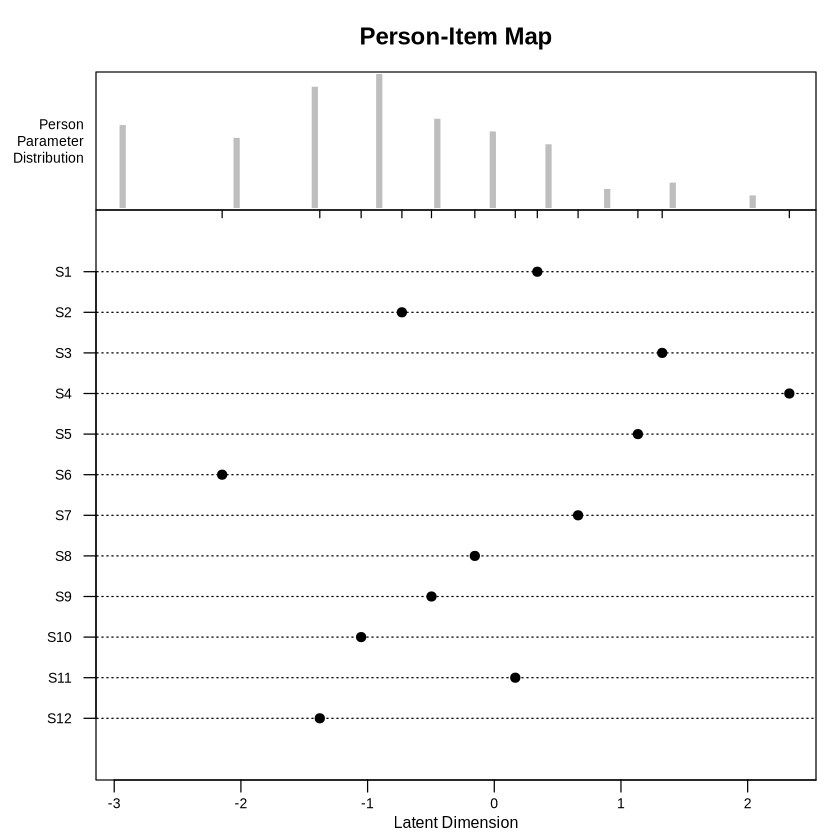

In [58]:
plotPImap(rasch_model_dea)

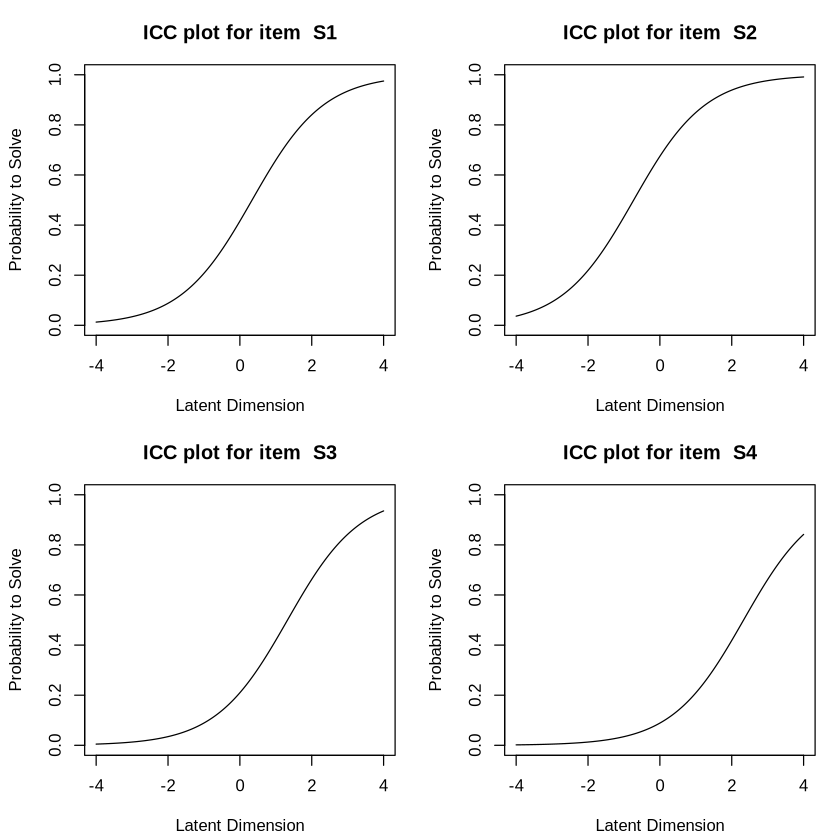

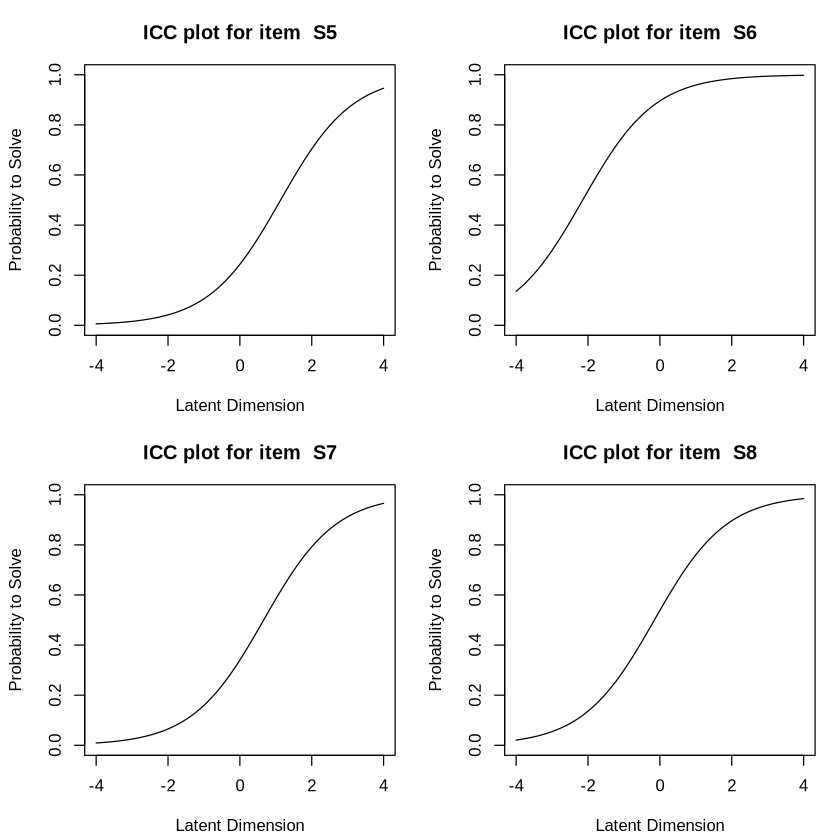

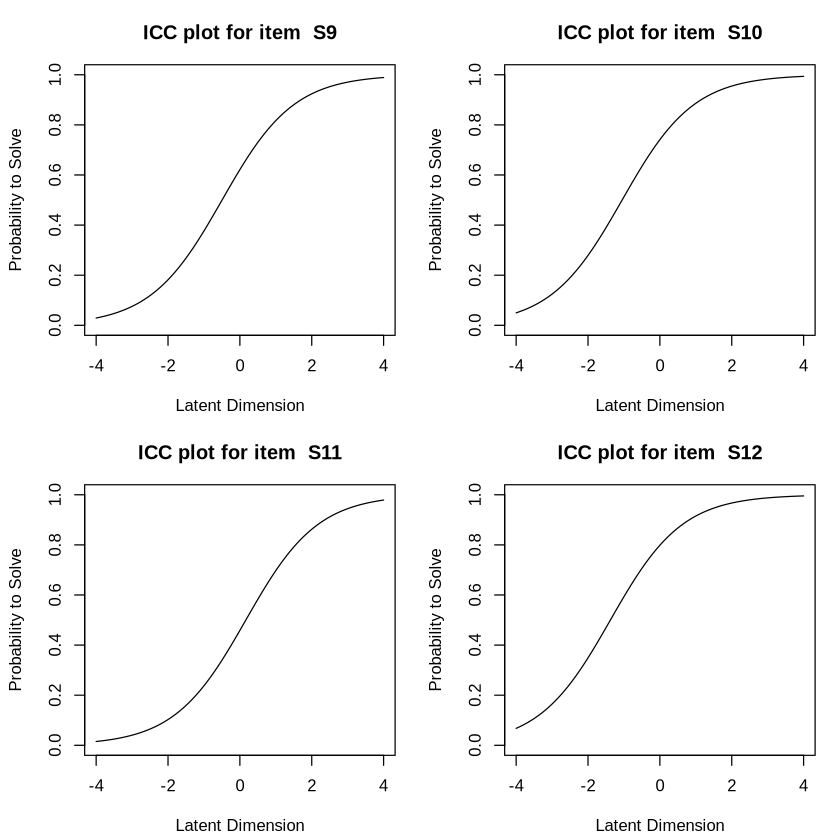

In [35]:
# Plot specific items (e.g., I1, I14, I26) to show the spread of difficulty
plotICC(rasch_model_dea)

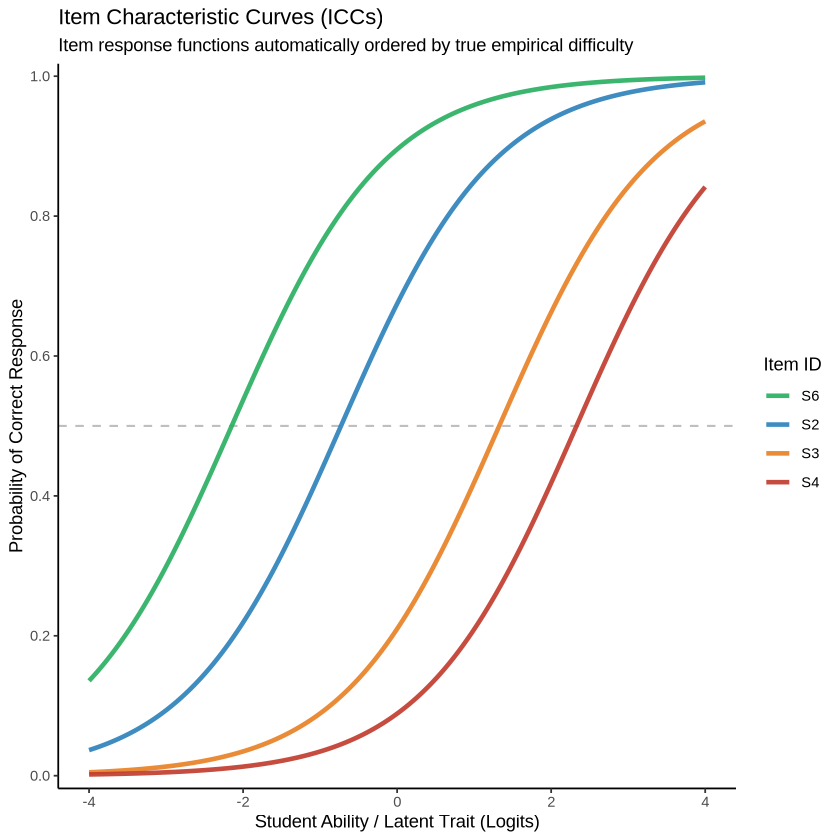

In [48]:
# STEP 1: Extract the TRUE difficulties (Do NOT multiply by -1)
item_diffs <- rasch_model_dea$etapar

selected_items <- c("S6", "S2", "S3", "S4")

filtered_diffs <- item_diffs[selected_items]
sorted_diffs <- sort(filtered_diffs)
ordered_item_names <- names(sorted_diffs)

# STEP 2: Build curves
theta_seq <- seq(-4, 4, length.out = 300)
icc_matrix <- data.frame(Theta = theta_seq)

for (item in ordered_item_names) {
  beta <- sorted_diffs[item]
  icc_matrix[[item]] <- exp(theta_seq - beta) / (1 + exp(theta_seq - beta))
}

icc_long <- pivot_longer(icc_matrix, cols = -Theta, names_to = "Item", values_to = "Probability")
icc_long$Item <- factor(icc_long$Item, levels = ordered_item_names)

# STEP 3 & 4: Plot
palette_colors <- c("#27AE60", "#2980B9", "#E67E22", "#C0392B")
names(palette_colors) <- ordered_item_names

ggplot(icc_long, aes(x = Theta, y = Probability, color = Item)) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray75", linewidth = 0.6) +
  geom_line(linewidth = 1.3, alpha = 0.9) +
  scale_color_manual(values = palette_colors) +
  scale_x_continuous(breaks = seq(-4, 4, 2)) +
  scale_y_continuous(breaks = seq(0, 1, 0.2), expand = c(0.01, 0.01)) +
  theme_classic() +
  labs(
    title = "Item Characteristic Curves (ICCs)",
    subtitle = "Item response functions automatically ordered by true empirical difficulty",
    x = "Student Ability / Latent Trait (Logits)",
    y = "Probability of Correct Response",
    color = "Item ID"
  )

- The 50% Reference Anchor: Including that subtle, dashed horizontal line at $P = 0.5$ is a huge win. In Rasch measurement, item difficulty is explicitly defined at the 50% probability mark. This line allows a reviewer to trace horizontally across the chart and instantly see exactly where each item anchors on the logit scale.

| Item | Curve Position | Inflection Point (at P=0.5) | Psychological Meaning to Report |
|------|----------------|------------------------------|--------------------------------|
| S4 | Far Left (Red) | $\approx -2.3$ Logits | The most basic gatekeeper item. Highly capable students find it trivial; only the lowest-ability students struggle here. |
| S2 | Mid-Left (Orange) | $\approx -0.7$ Logits | A moderately easy item that cleanly differentiates within the lower-middle ability spectrum. |
| S3 | Mid-Right (Blue) | $\approx +1.3$ Logits | A challenging question requiring above-average trait levels to pass. |
| S4 | Far Right (Green) | $\approx +2.3$ Logits | The scale's ceiling anchor. It requires an elite level of the latent trait to solve successfully. |

Warning message in geom_text_repel(aes(label = Item), size = 3.5, fontface = "bold", :
“Ignoring unknown parameters: `segment.linewidth`”


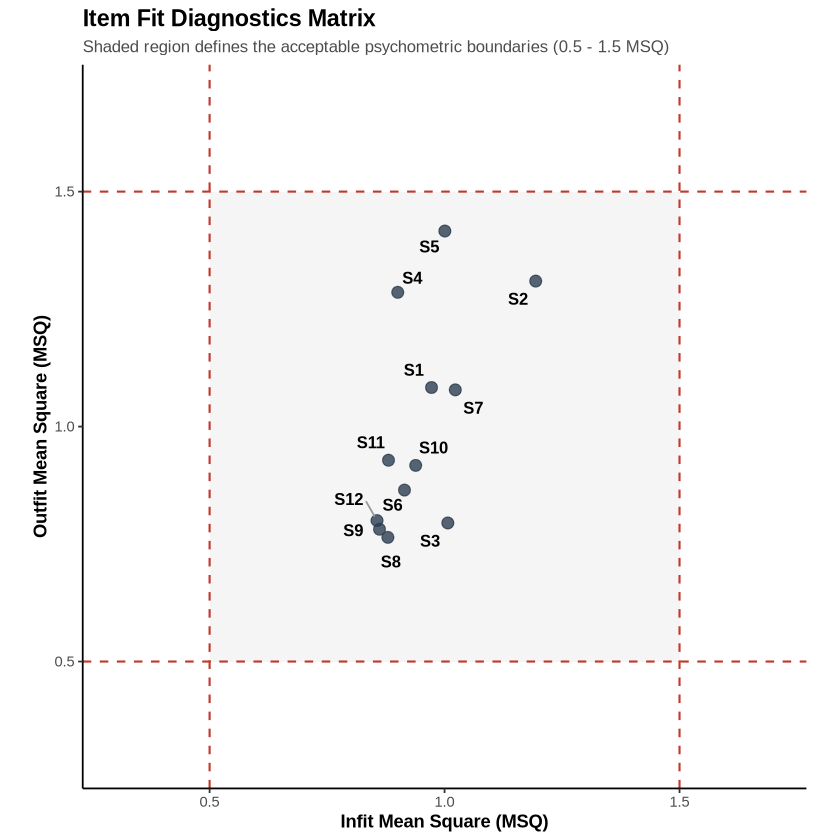

In [41]:
library(ggplot2)
library(ggrepel) # Essential for fixing the text collision

# 1. Prepare your data frame cleanly
fit_data <- data.frame(
  Item   = colnames(rasch_model_dea$X),
  Infit  = item_fit_stats$i.infitMSQ,
  Outfit = item_fit_stats$i.outfitMSQ
)

# 2. Build the Publication-Grade Matrix
ggplot(fit_data, aes(x = Infit, y = Outfit)) +
  # Highlight the "Safe Zone" with a subtle shaded background box
  geom_rect(aes(xmin = 0.5, xmax = 1.5, ymin = 0.5, ymax = 1.5),
            fill = "gray96", color = NA) +
  
  # Add the golden boundary dashed lines
  geom_vline(xintercept = c(0.5, 1.5), linetype = "dashed", color = "#C0392B", linewidth = 0.6) +
  geom_hline(yintercept = c(0.5, 1.5), linetype = "dashed", color = "#C0392B", linewidth = 0.6) +
  
  # Plot the high-contrast data points
  geom_point(color = "#2C3E50", size = 3, alpha = 0.8) +
  
  # Fix the overlapping text using ggrepel
  geom_text_repel(aes(label = Item),
                  size = 3.5,
                  fontface = "bold",
                  box.padding = 0.4,       # Distance around text
                  point.padding = 0.3,     # Distance from data dot
                  max.overlaps = Inf,      # Force all labels to show
                  segment.color = "gray60", # Color of the connector line
                  segment.linewidth = 0.4) +
  
  # Clean up scales and force a perfect square layout
  scale_x_continuous(limits = c(0.3, 1.7), breaks = seq(0.5, 1.5, 0.5)) +
  scale_y_continuous(limits = c(0.3, 1.7), breaks = seq(0.5, 1.5, 0.5)) +
  coord_fixed() + # Forces a perfect 1:1 geometric aspect ratio
  theme_classic() +
  
  # Professional styling and typography
  labs(
    title = "Item Fit Diagnostics Matrix",
    subtitle = "Shaded region defines the acceptable psychometric boundaries (0.5 - 1.5 MSQ)",
    x = "Infit Mean Square (MSQ)",
    y = "Outfit Mean Square (MSQ)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10, color = "gray30"),
    axis.title = element_text(face = "bold"),
    aspect.ratio = 1 # Hard locks the square format
  )

### The Item Fit Diagnostics Matrix (Construct Validity)
Maps Infit Mean Square (MSQ) on the X-axis against Outfit Mean Square (MSQ) on the Y-axis. This proves your scale's Unidimensionality (that it measures one single trait cleanly without being contaminated by outside noise).

#### 1. Reading the Parameters
- Infit MSQ (Information-Weighted): Sensitive to unexpected response patterns close to an item's difficulty level (e.g., an average student missing an average question due to confusing wording).
- Outfit MSQ (Outlier-Sensitive): Sensitive to unexpected responses far from an item's difficulty level (e.g., a low-ability student guessing a highly advanced question correctly).

#### 2. The Verdict of the "Safe Zone" Box
The light gray shaded box frames the strict psychometric boundaries of $0.5$ to $1.5$ MSQ.
| Fit Zone | Mathematical Interpretation | Structural Impact | Your Data's Status |
|----------|---------------------------|-------------------|--------------------|
| $> 1.5$ (Underfit) | Too much random noise; unmodeled error. | Degrades and contaminates the measurement ruler. | Completely Clear. Zero items cross this boundary. |
| $0.5 \text{ to } 1.5$ | Data conforms cleanly to the Rasch model. | High validity; stable and predictable intervals. | All 12 items sit securely inside this box. |
| $< 0.5$ (Overfit) | Too predictable; deterministic data redundancy. | Artificially inflates reliability metrics. | Completely Clear. No items drop below the floor. |

3. Detailed Item Diagnostics
- The High-End Boundaries (S5 and S2): S5 sits near the top ceiling ($\text{Outfit} \approx 1.41$) and S2 sits out to the right ($\text{Infit} \approx 1.21$). While they exhibit slightly higher variance than the rest of the pack, they remain safely under the $1.5$ threshold. They add unique breadth to the test without degrading its structure.
- The High-Precision Cluster (S12, S9, S8): Thanks to the ggrepel tracking, you can clearly see them separated at the bottom left ($\approx 0.75$ MSQ). These items are highly stable and track very closely to the model's theoretical expectations.

#### Synthesis: How to Present This in Your Thesis Defense
When you stand before your committee, weave these three visuals into a single cohesive story:

1. Start with Construct Validity (The Fit Matrix): "First, I verified the structural integrity of the scale. As shown in the Fit Diagnostics Matrix, all items cluster cleanly within the strict 0.5 to 1.5 MSQ boundaries, proving the instrument is unidimensional and free from distorting noise."

2. Move to Scale Behavior (The ICC Plot): "Next, the Item Characteristic Curves illustrate a highly stable, invariant hierarchy of item difficulties, cascading perfectly from our baseline milestone, S6, up to our maximum ceiling anchor, S4."

3. Deliver the Critical Scientific Insight (The Wright Map): "However, mapping these items against our sample via the Wright Map reveals a significant targeting misalignment. Our student population mean sits a full logit below the test mean. Furthermore, the floor gap between -2.5 and -4.0 logits highlights a critical measurement blind spot. While our tool is highly valid in its structure, future iterations must include easier items to accurately map out and support lower-performing students."